In [180]:
import numpy as np
import scipy.sparse as sp
from numba import njit, prange


@njit
def compute_weights(mesh, indexes):
    weighs = np.zeros((*mesh.shape, 7), dtype=np.float64)

    n_j = mesh.shape[1]
    n_k = mesh.shape[2]
    for i in prange(indexes.shape[0]):
        ind = indexes[i]
        i = ind//(n_j*n_k)
        j = (ind % (n_j*n_k))//n_k
        k = (ind % (n_j*n_k)) % n_k
        
        w_central = 0

        weighs[i, j, k, 0] = mesh[i+1, j, k]
        w_central += mesh[i+1, j, k]
    
        weighs[i, j, k, 1] = mesh[i-1, j, k]
        w_central += mesh[i-1, j, k]

        weighs[i, j, k, 2] = mesh[i, j + 1, k]
        w_central += mesh[i, j + 1, k]
    
        weighs[i, j, k, 3] = mesh[i, j-1, k]
        w_central += mesh[i, j-1, k]

        weighs[i, j, k, 4] = mesh[i, j, k+1]
        w_central += mesh[i, j, k+1]

        weighs[i, j, k, 5] = mesh[i, j, k-1]
        w_central += mesh[i, j, k-1]

        weighs[i, j, k, 6] = - w_central

    return weighs


def compute_sparse_weights(mesh, diffusion, indexes):

    ijk = np.array(np.unravel_index(indexes, mesh.shape))
    rows = np.empty((len(ijk), 2, len(indexes)), dtype=np.int64)
    cols = np.empty((len(ijk), 2, len(indexes)), dtype=np.int64)

    for i_axis in range(len(ijk)):
        for i, neighbor in enumerate([-1, 1]):
            neighbors = ijk.copy()
            neighbors[i_axis] += neighbor
            rows[i_axis, i, :] = indexes
            cols[i_axis, i, :] = np.ravel_multi_index(neighbors, mesh.shape)

    rows = rows.flatten()
    cols = cols.flatten()

    # data = 0.5 * mesh.flat[cols] * (diffusion.flat[cols] + diffusion.flat[rows])
    data = mesh.flat[cols]
    rows = rows[data > 0]
    cols = cols[data > 0]
    data = data[data > 0]

    c_indexes = np.zeros(mesh.size, dtype=np.int64)
    c_indexes[indexes] = np.arange(len(indexes))
    rows = c_indexes[rows]
    cols = c_indexes[cols]

    # print(rows)
    # print(cols)
    # print(data)

    size = len(indexes)
    shape = (size, size)
    A = sp.csr_matrix((data, (rows, cols)), shape=shape)
    row_sums = np.array(A.sum(axis=1)).ravel()
    D = sp.diags(-row_sums, offsets=0, format='csr')
    A_new = A + D
    return A_new.tocsr()

[ 0  3  6  9 12]
[0 1 2 0 1 3 0 2 3 1 2 3]
[0 0 0 1 1 1 2 2 2 3 3 3]
[0 1 2 0 1 3 0 2 3 1 2 3]
[-2.  1.  1.  1. -2.  1.  1. -2.  1.  1.  1. -2.]


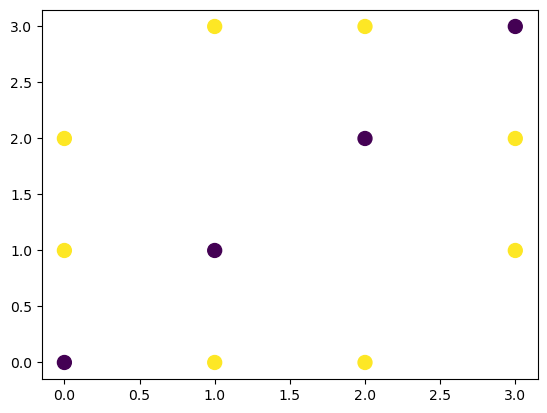

In [181]:
import matplotlib.pyplot as plt


mesh = np.ones((4, 4))
mesh[0, :] = 0
mesh[-1, :] = 0
mesh[:, 0] = 0
mesh[:, -1] = 0

indexes = np.flatnonzero(mesh)
diffusion = np.ones_like(mesh, dtype=np.float64)

a_scipy = compute_sparse_weights(mesh, diffusion, indexes)

print(a_scipy.indptr)
print(a_scipy.indices)

rows, cols = a_scipy.nonzero()

print(rows)
print(cols)
print(a_scipy.data)

plt.scatter(rows, cols, s=100, c=a_scipy.data, cmap='viridis')
plt.show()
# %timeit weighs = compute_weights(mesh, indexes)

indptr  = [0, 0, 0, 0, 0, 0, 3, 6, 6, 6, 9, 12]
indices = [5, 6, 9, 5, 6, 10, 5, 9, 10, 6, 9, 10]
data    = [-2., 1., 1., 1., -2., 1., 1., -2., 1., 1., 1., -2.]


In [ ]:
mesh = np.ones((200, 200, 20))
mesh[0, :, :] = 0
mesh[-1, :, :] = 0
mesh[:, 0, :] = 0
mesh[:, -1, :] = 0
mesh[:, :, 0] = 0
mesh[:, :, -1] = 0

indexes = np.flatnonzero(mesh)
diffusion = np.ones_like(mesh, dtype=np.float64)

%timeit a_scipy = compute_sparse_weights(mesh, diffusion, indexes)
%timeit weighs = compute_weights(mesh, indexes)

185 ms ± 14.4 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
8.76 ms ± 284 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [183]:
from numba import prange, njit
from threadpoolctl import threadpool_limits


@njit(parallel=True, fastmath=True)
def diffusion_numba(u_new, u, weighs, indexes, rhs):
    n_j = u.shape[1]
    n_k = u.shape[2]
    for i in prange(indexes.shape[0]):
        ind = indexes[i]
        i = ind//(n_j*n_k)
        j = (ind % (n_j*n_k))//n_k
        k = (ind % (n_j*n_k)) % n_k
        u_new[i, j, k] += (weighs[i, j, k, 0] * u[i + 1, j, k] + 
                           weighs[i, j, k, 1] * u[i - 1, j, k] +
                           weighs[i, j, k, 2] * u[i, j + 1, k] +
                           weighs[i, j, k, 3] * u[i, j - 1, k] +
                           weighs[i, j, k, 4] * u[i, j, k + 1] +
                           weighs[i, j, k, 5] * u[i, j, k - 1] + 
                           weighs[i, j, k, 6] * u[i, j, k]) + rhs[i, j, k]

    return u_new


@njit(parallel=True, fastmath=True)
def diffusion_sparse_numba(indptr, indices, data, u_new, u, rhs, indexes):
    n_rows = indptr.size - 1
    
    for i in prange(n_rows):
        start = indptr[i]
        end = indptr[i + 1]
        if start == end:
            continue
        acc = 0.0
        for j in range(start, end):
            jj = indices[j]
            jj = indexes[jj]
            acc += data[j] * u.flat[jj]
        
        ii = indexes[i]
        u_new.flat[ii] = acc + rhs.flat[ii]
    
    return u_new


@threadpool_limits.wrap(limits=1, user_api="blas")
def diffusion_sparse_scipy(A, u):
    return A @ u


In [185]:
from pathlib import Path
import numpy as np
import scipy.sparse as sp


path = Path("/Users/arstanbek/Projects/fibrosis/Finitewave/examples/data/mesh.npy")

# mesh = np.load(path)

mesh = np.ones((400, 400, 10))
mesh[np.random.random(mesh.shape) < -0.5] = 0
mesh[0, :, :] = 0
mesh[-1, :, :] = 0
mesh[:, 0, :] = 0
mesh[:, -1, :] = 0
mesh[:, :, 0] = 0
mesh[:, :, -1] = 0

indexes = np.flatnonzero(mesh)

diffusion = np.ones_like(mesh).astype(np.float64)
u = np.random.random(mesh.shape).astype(np.float64)
rhs = np.random.random(mesh.shape).astype(np.float64)
u_new = np.zeros_like(u)

u_flat = u.flatten()
u_new_flat = u_new.flatten()
rhs_flat = rhs.flatten()

a_scipy = compute_sparse_weights(mesh, diffusion, indexes)
weighs = compute_weights(mesh, indexes)

x = diffusion_numba(u_new, u, weighs, indexes, rhs)
x = diffusion_sparse_numba(a_scipy.indptr, a_scipy.indices, a_scipy.data, u_new, u, rhs, indexes)

%timeit x = diffusion_numba(u_new, u, weighs, indexes, rhs)
%timeit x = diffusion_sparse_numba(a_scipy.indptr, a_scipy.indices, a_scipy.data, u_new, u, rhs, indexes)
# %timeit a_scipy @ u_flat

3.57 ms ± 16.8 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)
2.2 ms ± 63 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [74]:
%timeit u_new + rhs

584 µs ± 17.9 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


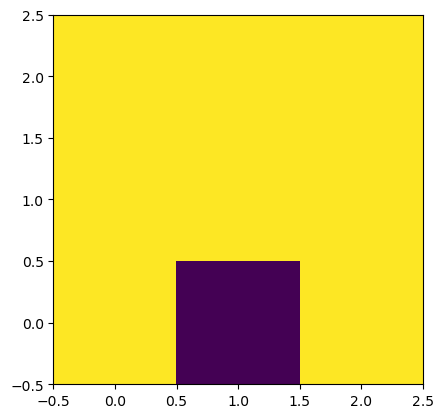

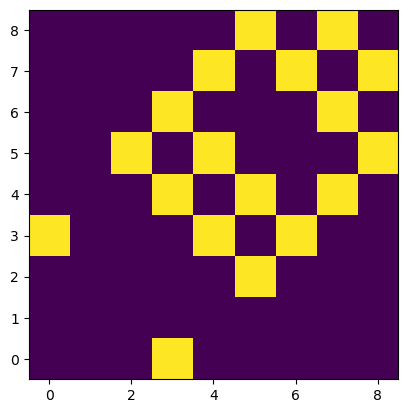

In [219]:
class IsotropicFirstOrderBoundary:
    def __init__(self):
        pass

    def compute(self, mesh, indexes):
        ijk = np.array(np.unravel_index(indexes, mesh.shape))
        rows = []
        cols = []
        weights = []

        for i_axis in range(len(ijk)):
            neighbors_left = ijk.copy()
            neighbors_right = ijk.copy()
            neighbors_left[i_axis] -= 1
            neighbors_right[i_axis] += 1

            left = self.empty_neighbors(neighbors_left, mesh, i_axis)
            right = self.empty_neighbors(neighbors_right, mesh, i_axis)
            left, right = self.treat_boundary(left, right)
            
            rows.append(indexes[left > 0])
            cols.append(np.ravel_multi_index(neighbors_left[:, left > 0],
                                             mesh.shape))
            weights.append(left[left > 0])
            
            rows.append(indexes[right > 0])
            cols.append(np.ravel_multi_index(neighbors_right[:, right > 0],
                                             mesh.shape))
            weights.append(right[right > 0])

        rows = np.concatenate(rows)
        cols = np.concatenate(cols)
        weights = np.concatenate(weights)
        return rows, cols, weights

    def empty_neighbors(self, neighbors, mesh, i_axis):
        mask = ((neighbors[i_axis] >= 0) &
                (neighbors[i_axis] < mesh.shape[i_axis]))
        mask[mask] = mesh[tuple(neighbors[:, mask])] > 0
        return mask.astype(np.float64)

    def treat_boundary(self, left, right):
        return left, right


mesh = np.ones((3, 3))
mesh[0, 1] = 0
indexes = np.flatnonzero(mesh > 0)

boundary = IsotropicFirstOrderBoundary()
rows, cols, weights = boundary.compute(mesh, indexes)

res = np.zeros((9, 9))
res[rows, cols] = weights

plt.figure()
plt.imshow(mesh, origin="lower")
plt.show()

plt.figure()
plt.imshow(res, origin="lower")
plt.show()


In [ ]:
import numpy as np
from scipy import sparse as sp



class IsotropicStencil:
    """
    This class computes the weights for diffusion on a 2D using an isotropic
    stencil. The stencil includes 5 points: the central point and the
    four neighbors.

    The method assumes weights being used in the following order:

    - ``w[i, j, 0] : (i-1, j)``,
    - ``w[i, j, 1] : (i, j-1)``,
    - ``w[i, j, 2] : (i, j)``,
    - ``w[i, j, 3] : (i, j+1)``,
    - ``w[i, j, 4] : (i-1, j)``.

    Notes
    -----
    The method can handle heterogeneity in the diffusion coefficients given
    by the ``conductivity`` parameter.
    """

    def __init__(self):
        self.boundary = IsotropicFirstOrderBoundary()

    def assemble_matrices(self, simulation):
        """
        Computes the weights for isotropic diffusion in 2D.

        Parameters
        ----------
        simulation : simulation
            A simulation object containing the simulation parameters.

        Returns
        -------
        numpy.ndarray
            The weights for isotropic diffusion in 2D.
        """
        tissue = simulation.cardiac_tissue
        model = simulation.cardiac_model

        d_model = model.D_model
        mesh = tissue.mesh.copy()
        mesh[mesh != 1] = 0

        conductivity = tissue.conductivity
        conductivity *= np.ones_like(mesh, dtype=simulation.npfloat)
        diffusion = d_model * conductivity / simulation.dr**2

        stiff, mass = self.compute_weights_sparse(mesh, diffusion,
                                                  tissue.myo_indexes)
        return stiff, mass

    def compute_weights_sparse(self, mesh, diffusion, indexes):
        rows, cols, weights = self.boundary.compute(mesh, indexes)
        weights = weights.astype(diffusion.dtype)
        weights *= 0.5 * (diffusion.flat[cols] + diffusion.flat[rows])

        c_indexes = np.zeros(mesh.size, dtype=np.int64)
        c_indexes[indexes] = np.arange(len(indexes))
        rows = c_indexes[rows]
        cols = c_indexes[cols]

        size = len(indexes)
        shape = (size, size)
        K = sp.csr_matrix((weights, (rows, cols)), shape=shape)
        row_sums = np.array(K.sum(axis=1)).ravel()
        D = sp.diags(-row_sums, offsets=0, format='csr')
        K_new = K + D
        M = sp.diags([1.0], [0], shape=shape)
        return K_new.tocsr(), M.tocsr()


class CardiacTissue:
    def __init__(self):
        self.mesh = np.ones((3, 3), dtype=np.int64)
        self.conductivity = 1.

    @property
    def myo_indexes(self):
        return np.flatnonzero(self.mesh == 1)

class CardiacModel:
    def __init__(self):
        self.D_model = 1.0

class Simulation:
    def __init__(self):
        self.cardiac_tissue = CardiacTissue()
        self.cardiac_model = CardiacModel()
        self.dr = 1.0
        self.dt = 1.0
        self.npfloat = np.float64

simulation = Simulation()

stencil = IsotropicStencil()
stiff, mass = stencil.assemble_matrices(simulation)

print(stiff)
print(mass)


UFuncTypeError: Cannot cast ufunc 'multiply' output from dtype('float64') to dtype('int64') with casting rule 'same_kind'